# Imports

In [1]:
from data_explorer_class import DataExplorer 
from data_cleaning_class import DataCleaner
import pandas as pd
import numpy as np 
import lightgbm as lgb
import itertools
from sklearn.model_selection import GroupKFold , GridSearchCV  , GroupShuffleSplit , train_test_split
from sklearn.metrics import mean_squared_error , r2_score
import os
import time
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
import shap
from sklearn.inspection import permutation_importance
import random
RANDOM = 42
random.seed(RANDOM)


pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [2]:
script_dir = os.getcwd()
train_path = os.path.join(script_dir , "train.csv")
test_path  = os.path.join(script_dir , "test.csv")
solution_path = os.path.join(script_dir,"solution.csv")


train_df  = pd.read_csv(train_path)
test_df   = pd.read_csv(test_path)
solution_df = pd.read_csv(solution_path)

target = 'player_rating'
ID     = 'player_id'

# Preprocessing  

## Data Exploring ~ before cleaning

In [ ]:
explore_df = DataExplorer(train_df)
explore_df.exploration()

## Data Cleaning

In [3]:
#print(train_df["minutes_played"].value_counts()) #there are 18524 of 0 minutes played rows
train_df = train_df[train_df['minutes_played'] > 0].reset_index(drop=True) 

###dropping unrelated to performance cols
cols_to_drop = [
    'Id', 'player_name', 'match_id', 'match_date', 'stadium', 'city',
    'jersey_number', 'opponent_team', 'tournament_stage',
    'nationality', 'team', 'club_name','preferred_foot', 'performance_score'
]
train_df = train_df.drop(columns = cols_to_drop)

#hot encoding
print ("Positions are:")
print(train_df["position"].value_counts())

print ("Match results are")
print(train_df["match_result"].value_counts())

train_df = pd.get_dummies(train_df, columns=['position'], prefix='pos')
train_df = pd.get_dummies(train_df, columns=['match_result'], prefix='result')
print (train_df.head(5))


train_df_cleaned = DataCleaner(train_df).clean_df()

Positions are:
position
Defender      9150
Midfielder    8147
Forward       6078
Goalkeeper    1685
Name: count, dtype: int64
Match results are
match_result
L    9230
W    9226
D    6604
Name: count, dtype: int64
  player_id  age  height_cm  weight_kg  market_value_eur  goals_team  \
0    P00056   24        176         78          15191371           1   
1    P00058   27        188         80          12330574           1   
2    P00067   25        183         78           9912074           1   
3    P00069   24        181         81          16807939           1   
4    P00070   19        178         75           4918927           1   

   goals_opponent  minutes_played  goals  assists  shots  shots_on_target  \
0               0              71      0        0      0                0   
1               0              79      0        0      0                0   
2               0              35      0        0      0                0   
3               0              85      0      

## Exploring after cleaning 

-----------------
DataSet Shape is (25060, 66)
-----------------
-----------------


=== STATISTICS ===
                age     height_cm     weight_kg  market_value_eur  \
count  25060.000000  25060.000000  25060.000000      2.506000e+04   
mean      26.292618    181.162809     75.664725      2.106932e+07   
std        3.982329      6.223102      3.890573      2.802099e+07   
min       17.000000    163.000000     65.000000      5.288220e+05   
25%       24.000000    177.000000     73.000000      4.759435e+06   
50%       26.000000    182.000000     76.000000      1.059048e+07   
75%       29.000000    186.000000     78.000000      2.527637e+07   
99%       35.000000    194.000000     84.000000      1.420593e+08   
max       39.000000    200.000000     85.000000      2.000000e+08   

         goals_team  goals_opponent  minutes_played         goals  \
count  25060.000000    25060.000000    25060.000000  25060.000000   
mean       1.328811        1.328492       62.539545      0.096369  

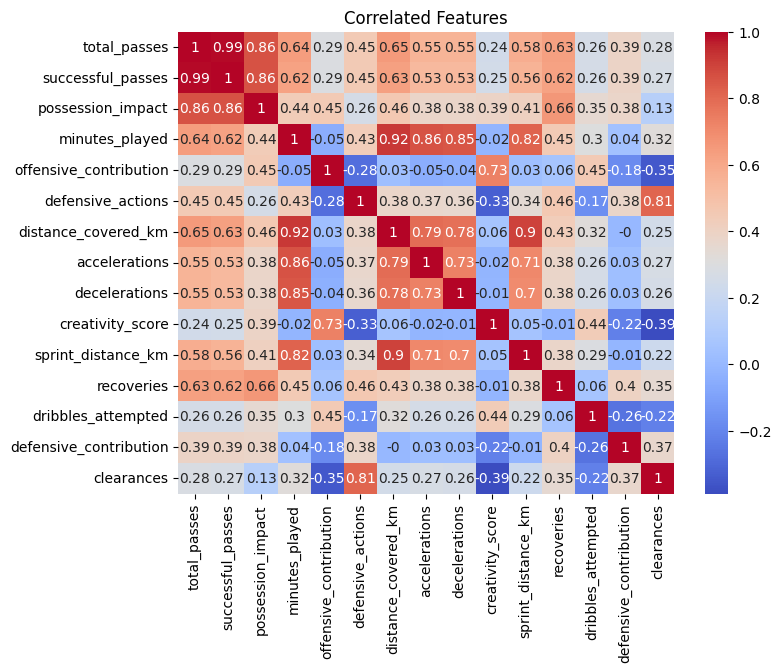


Correlation with player_rating
consistency_score           0.468972
pressure_resistance         0.443285
market_value_eur            0.409850
possession_impact           0.373480
offensive_contribution      0.342504
creativity_score            0.273214
total_passes                0.261418
successful_passes           0.252029
defensive_contribution      0.210164
goals                       0.185207
recoveries                  0.168782
dribbles_attempted          0.158449
successful_dribbles         0.152710
key_passes                  0.148117
shots                       0.142634
assists                     0.140080
player_of_match_awards      0.127195
stamina_score               0.119893
shots_on_target             0.116225
clutch_performance_score    0.089408
total_goals_tournament      0.085667
expected_assists_xa         0.070723
total_assists_tournament    0.067062
expected_goals_xg           0.064356
goals_team                  0.061323
goals_opponent             -0.057291
fouls_

In [4]:
cleaned_explorer = DataExplorer(train_df_cleaned).exploration()
print (train_df_cleaned.head(5))

## Feature Engineering

-----------------
DataSet Shape is (25060, 93)
-----------------
-----------------


=== STATISTICS ===
                age     height_cm     weight_kg  market_value_eur  \
count  25060.000000  25060.000000  25060.000000      2.506000e+04   
mean      26.292618    181.162809     75.664725      2.106932e+07   
std        3.982329      6.223102      3.890573      2.802099e+07   
min       17.000000    163.000000     65.000000      5.288220e+05   
25%       24.000000    177.000000     73.000000      4.759435e+06   
50%       26.000000    182.000000     76.000000      1.059048e+07   
75%       29.000000    186.000000     78.000000      2.527637e+07   
99%       35.000000    194.000000     84.000000      1.420593e+08   
max       39.000000    200.000000     85.000000      2.000000e+08   

         goals_team  goals_opponent  minutes_played         goals  \
count  25060.000000    25060.000000    25060.000000  25060.000000   
mean       1.328811        1.328492       62.539545      0.096369  

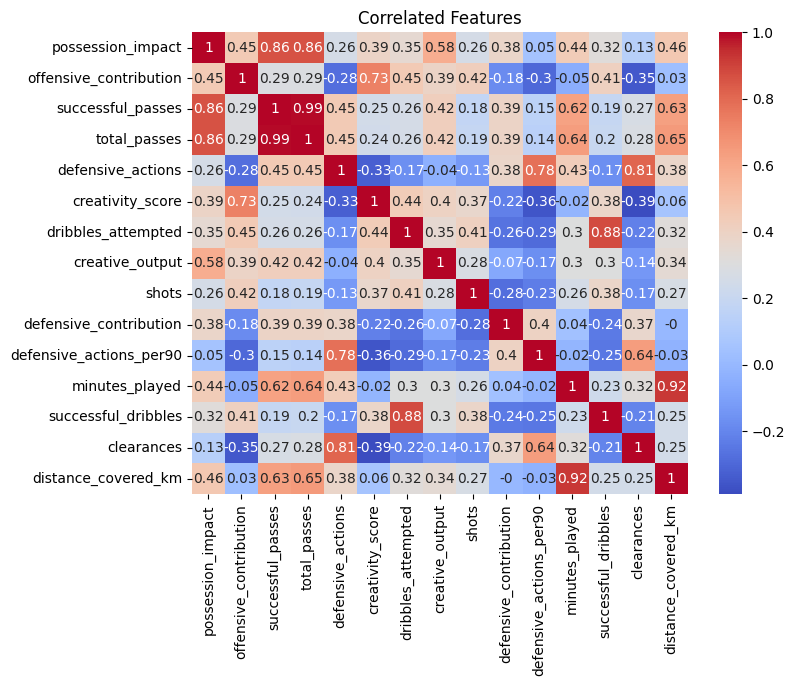


Correlation with player_rating
consistency_score           0.468972
pressure_resistance         0.443285
net_contribution            0.436264
market_value_eur            0.409850
possession_impact           0.373480
offensive_contribution      0.342504
successful_passes_per90     0.320693
creativity_score            0.273214
total_passes                0.261418
successful_passes           0.252029
defensive_contribution      0.210164
goal_involvement_per90      0.186157
goals                       0.185207
creative_output             0.173768
recoveries                  0.168782
goals_overperformance       0.165003
recoveries_per90            0.163570
dribbles_attempted          0.158449
successful_dribbles         0.152710
goals_per90                 0.152400
team_goal_share             0.148836
key_passes                  0.148117
dribbles_attempted_per90    0.143102
shots                       0.142634
assists                     0.140080
shot_conversion             0.135746
key_pa

In [5]:
#if teams winning tend to have higher scores 
train_df_cleaned['goal_difference'] = (train_df_cleaned['goals_team'] - train_df_cleaned['goals_opponent'])

#i'm hoping that'll give a sense of the expected being the 'floor' of a player
train_df_cleaned['goals_overperformance'] = (train_df_cleaned['goals'] - train_df_cleaned['expected_goals_xg'])
train_df_cleaned['assist_overperformance'] = (train_df_cleaned['assists'] - train_df_cleaned['expected_assists_xa'])

train_df_cleaned['shot_conversion'] = np.where(train_df_cleaned['shots'] > 0,
    train_df_cleaned['goals'] / train_df_cleaned['shots']
    ,0
)

train_df_cleaned['dribble_success_rate'] = np.where(
    train_df_cleaned['dribbles_attempted'] > 0,
    train_df_cleaned['successful_dribbles'] / train_df_cleaned['dribbles_attempted'],
    0
)

#normalizing actions by time of minutes played
per_90_cols = [
    'goals', 'assists', 'shots', 'shots_on_target', 'key_passes',
    'tackles', 'interceptions', 'recoveries', 'defensive_actions',
    'successful_passes', 'dribbles_attempted'
]

for col in per_90_cols:
    train_df_cleaned[f'{col}_per90'] = np.where(
        train_df_cleaned['minutes_played'] > 0,
        train_df_cleaned[col] / train_df_cleaned['minutes_played'] * 90,
        0
    )

train_df_cleaned['bmi'] = train_df_cleaned['weight_kg'] / ((train_df_cleaned['height_cm']/100) ** 2)


#-- Next features are added by AI recommendation of important parameters in soccers ratings
# i kept them since i'm filtering later so weak ones won't effect the model 

# xA per 90 (missing from your original per_90_cols list)
train_df_cleaned['xa_per90'] = np.where(
    train_df_cleaned['minutes_played'] > 0,
    train_df_cleaned['expected_assists_xa'] / train_df_cleaned['minutes_played'] * 90,
    0
)

# Defensive duel win rate — tackles+interceptions as "wins", fouls_committed as a rough proxy for lost duels
defensive_attempts = (
    train_df_cleaned['tackles'] + train_df_cleaned['interceptions'] + train_df_cleaned['fouls_committed']
)
train_df_cleaned['defensive_duel_win_rate'] = np.where(
    defensive_attempts > 0,
    (train_df_cleaned['tackles'] + train_df_cleaned['interceptions']) / defensive_attempts,
    0
)

# Aerial duel win rate
aerial_total = train_df_cleaned['aerial_duels_won'] + train_df_cleaned['aerial_duels_lost']
train_df_cleaned['aerial_duel_win_rate'] = np.where(
    aerial_total > 0,
    train_df_cleaned['aerial_duels_won'] / aerial_total,
    0
)


# Winning-context interaction — does scoring matter more/less depending on match outcome?
train_df_cleaned['goals_x_result_w'] = train_df_cleaned['goals'] * train_df_cleaned['result_w']

# Net positive contribution — reward productive actions, penalize discipline issues
train_df_cleaned['net_contribution'] = (
    train_df_cleaned['offensive_contribution'] + train_df_cleaned['defensive_contribution']
    - (train_df_cleaned['fouls_committed'] * 2)
)

# Shot accuracy (different from shot_conversion — this is precision, not finishing)
train_df_cleaned['shot_accuracy'] = np.where(
    train_df_cleaned['shots'] > 0,
    train_df_cleaned['shots_on_target'] / train_df_cleaned['shots'], 0
)

# Share of team's goals this player accounted for — direct measure of offensive importance
train_df_cleaned['team_goal_share'] = np.where(
    train_df_cleaned['goals_team'] > 0,
    train_df_cleaned['goals'] / train_df_cleaned['goals_team'], 0
)

# Combined underlying attacking threat (xG + xA) — captures quality of chances regardless of finishing luck
train_df_cleaned['combined_threat'] = (
    train_df_cleaned['expected_goals_xg'] + train_df_cleaned['expected_assists_xa']
)

# Combined actual output per 90 — goals+assists together, not separately
train_df_cleaned['goal_involvement_per90'] = np.where(
    train_df_cleaned['minutes_played'] > 0,
    (train_df_cleaned['goals'] + train_df_cleaned['assists']) / train_df_cleaned['minutes_played'] * 90, 0
)

# Chance creation beyond just assists — key passes that didn't convert still show creative output
train_df_cleaned['creative_output'] = train_df_cleaned['key_passes'] + train_df_cleaned['assists']

cleaned_explorer = DataExplorer(train_df_cleaned).exploration()

## XIA Analysis

### SHAP

In [6]:
X = train_df_cleaned.drop(columns=[target , ID])
y = train_df_cleaned[target]
groups = train_df_cleaned['player_id']
gkf = GroupKFold(n_splits= 5)

best_params = {
    'depth': 7,
    'learning_rate': 0.004047021608515087,
    'l2_leaf_reg': 3.9940737878718897,
    'min_data_in_leaf': 170,
    'random_strength': 29.862919866938373,
    'bagging_temperature': 9.11269381366412,
    'border_count': 200,
    'grow_policy': 'Lossguide',
    'leaf_estimation_iterations': 9,
    'rsm': 0.6550428091440278,
    'max_leaves': 58
}


model = CatBoostRegressor(iterations= 5000 , task_type= 'CPU' , random_seed= RANDOM , 
                          verbose = False , early_stopping_rounds=50 , **best_params)

gss = GroupShuffleSplit(n_splits= 1 , test_size=0.2 , random_state= RANDOM)
train_idx, val_idx = next(gss.split(X, y, groups=groups))
X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

model.fit(X_train , y_train)
explainer = shap.TreeExplainer(model= model)
shap_values = explainer.shap_values(X_val)

mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_importance = pd.Series(mean_abs_shap, index=X_val.columns).sort_values(ascending=False)
print ("Shap importance : ")
print(shap_importance)

# plots 
# shap.summary_plot(shap_values, X_val, plot_type='bar', max_display=20)
# shap.summary_plot(shap_values, X_val, max_display=20)

# shap.dependence_plot('performance_score', shap_values, X_val) 

Shap importance : 
consistency_score           0.182066
market_value_eur            0.150342
pressure_resistance         0.132980
net_contribution            0.124420
possession_impact           0.088039
defensive_contribution      0.066213
stamina_score               0.064715
offensive_contribution      0.057097
successful_passes_per90     0.055259
result_w                    0.045333
defensive_duel_win_rate     0.043081
creativity_score            0.040805
fouls_committed             0.037678
recoveries_per90            0.032792
goal_difference             0.030694
goals_overperformance       0.028809
assist_overperformance      0.026124
bmi                         0.025965
assists                     0.025458
result_d                    0.021130
dribbles_attempted_per90    0.019701
tackles_per90               0.018774
goal_involvement_per90      0.017588
team_goal_share             0.017345
result_l                    0.017215
total_passes                0.017111
shot_conversion    

### Permutation Importance 

In [7]:
permutation_results = permutation_importance(estimator= model , X= X_val , y = y_val , n_repeats= 10,
                                             random_state= RANDOM , scoring = 'neg_mean_squared_error' , n_jobs= -1)

perm_importance = pd.Series(
    permutation_results.importances_mean, index=X_val.columns
).sort_values(ascending=False)

perm_std = pd.Series(
    permutation_results.importances_std, index=X_val.columns
)

print(perm_importance)

consistency_score           0.021827
market_value_eur            0.015462
pressure_resistance         0.009901
possession_impact           0.008149
net_contribution            0.006071
defensive_contribution      0.003383
result_w                    0.003181
fouls_committed             0.002276
offensive_contribution      0.001943
successful_passes_per90     0.001880
creativity_score            0.001659
goals_overperformance       0.001281
goal_involvement_per90      0.000884
total_passes                0.000803
assists                     0.000796
team_goal_share             0.000773
assist_overperformance      0.000764
goal_difference             0.000754
defensive_duel_win_rate     0.000486
successful_passes           0.000345
dribbles_attempted_per90    0.000326
result_l                    0.000267
goals_opponent              0.000217
total_assists_tournament    0.000207
goals_x_result_w            0.000186
shot_conversion             0.000185
age                         0.000179
r

### Keeping only features that matter

In [8]:
#i've read in multiple articles that tree models almost don't suffer from non important features. but tunning on less rows will save time
permutation_threshold = 0.0049628269703006645
shap_threshold = 0.017375141081390738

keep_by_perm = perm_importance[perm_importance > permutation_threshold].index.tolist()
keep_by_shap = shap_importance[shap_importance >= shap_threshold].index.tolist()
keep_features = list(set(keep_by_perm) | set(keep_by_shap))


#keeping position cols because i believe it's really tree-important factor 
position_cols = ['pos_defender', 'pos_midfielder', 'pos_forward', 'pos_goalkeeper']
necessary_cols = ['player_id', 'player_rating']
final_feature_cols = list(dict.fromkeys(keep_features + position_cols))

print(f"Kept {len(final_feature_cols)} features "
      f"(perm-only: {len(keep_by_perm)}, shap-only: {len(keep_by_shap)}, "
      f"overlap: {len(set(keep_by_perm) & set(keep_by_shap))})")

X_pruned = X[final_feature_cols]

folds=[]
for train_idx, val_idx in gkf.split(X, y, groups=groups):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    m = CatBoostRegressor(
        iterations=5000, random_seed=RANDOM, verbose=False,
        early_stopping_rounds=50, **best_params
    )
    m.fit(X_train, y_train, eval_set=(X_val, y_val))
    preds = m.predict(X_val)
    folds.append(mean_squared_error(y_val, preds))

print(f"Full feature set ({X.shape[1]} features) MSE: "
      f"{np.mean(folds):.4f} (+/- {np.std(folds):.4f})")

# --- pruned feature set, same tuned hyperparams, same folds ---
folds_pruned = []
for train_idx, val_idx in gkf.split(X_pruned, y, groups=groups):
    X_train, X_val = X_pruned.iloc[train_idx], X_pruned.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    m = CatBoostRegressor(
        iterations=5000, random_seed=RANDOM, verbose=False,
        early_stopping_rounds=50, **best_params
    )
    m.fit(X_train, y_train, eval_set=(X_val, y_val))
    preds = m.predict(X_val)
    folds_pruned.append(mean_squared_error(y_val, preds))

print(f"Pruned feature set ({len(final_feature_cols)} features) MSE: "
      f"{np.mean(folds_pruned):.4f} (+/- {np.std(folds_pruned):.4f})")

delta = np.mean(folds_pruned) - np.mean(folds)
print(f"Delta (pruned - full): {delta:+.4f}  "
      f"({'pruned is worse' if delta > 0 else 'pruned holds up or improves'})")

# applying the pruning since it helped
print(final_feature_cols)
train_df_cleaned = train_df_cleaned[final_feature_cols + necessary_cols]
X = X_pruned


Kept 27 features (perm-only: 5, shap-only: 23, overlap: 5)
Full feature set (91 features) MSE: 0.3771 (+/- 0.0042)
Pruned feature set (27 features) MSE: 0.3764 (+/- 0.0045)
Delta (pruned - full): -0.0007  (pruned holds up or improves)
['goals_overperformance', 'assists', 'net_contribution', 'successful_passes_per90', 'recoveries_per90', 'creativity_score', 'offensive_contribution', 'possession_impact', 'market_value_eur', 'consistency_score', 'stamina_score', 'assist_overperformance', 'bmi', 'result_d', 'dribbles_attempted_per90', 'fouls_committed', 'defensive_duel_win_rate', 'tackles_per90', 'defensive_contribution', 'result_w', 'goal_involvement_per90', 'goal_difference', 'pressure_resistance', 'pos_defender', 'pos_midfielder', 'pos_forward', 'pos_goalkeeper']


# Model Testing

## lightgbm

In [ ]:
fold_scores = []
models = []

for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups=groups)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = lgb.LGBMRegressor(n_estimators= 2000, learning_rate= 0.03 , num_leaves= 31,
                            max_depth= -1 , min_child_samples= 20, subsample=0.8 , colsample_bytree= 0.8 , reg_alpha= 0.1,
                            reg_lambda= 0.1, random_state= 42
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )

    preds = model.predict(X_val)
    fold_scores.append(mean_squared_error(y_val, preds))

print(f"\nMean CV MSE: {np.mean(fold_scores):.4f} (+/- {np.std(fold_scores):.4f})")


## Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor

fold_scores_rf = []
for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups=groups)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = RandomForestRegressor(
        n_estimators=500, max_depth = 12 , min_samples_leaf = 5 , max_features='sqrt',
        n_jobs=-1,
        random_state=42
    )
    model.fit(X_train, y_train)

    preds = model.predict(X_val)
    mse = mean_squared_error(y_val, preds)
    fold_scores_rf.append(mse)

print(f"\nMean CV MSE {np.mean(fold_scores_rf):.4f} (+/- {np.std(fold_scores_rf):.4f})")

## XGBoost

In [ ]:
import xgboost as xgb

fold_scores_xgb = []
for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups=groups)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = xgb.XGBRegressor(
        n_estimators=2000,
        learning_rate=0.03,
        max_depth=6,                 # XGB default-ish, controls tree complexity directly (unlike LightGBM's leaf-wise growth)
        min_child_weight=5,          # analogous to min_child_samples — guards rare-event overfitting
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,               # XGB default L2 is already meaningful, keep it higher than alpha
        random_state=42,
        early_stopping_rounds=50,
        eval_metric='rmse'
    )
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    preds = model.predict(X_val)
    mse = mean_squared_error(y_val, preds)
    fold_scores_xgb.append(mse)

print(f"\nMean CV MSE : {np.mean(fold_scores_xgb):.4f} (+/- {np.std(fold_scores_xgb):.4f})")

## Catboost

In [ ]:
from catboost import CatBoostRegressor

fold_scores_cb = []
for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups=groups)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = CatBoostRegressor(
        iterations=2000, depth=6,random_seed=42,
        learning_rate=0.03,
        early_stopping_rounds=50,
        verbose=False
    )
    model.fit(X_train, y_train, eval_set=(X_val, y_val))

    preds = model.predict(X_val)
    mse = mean_squared_error(y_val, preds)
    fold_scores_cb.append(mse)

print(f"\nMean CV MSE {np.mean(fold_scores_cb):.4f} (+/- {np.std(fold_scores_cb):.4f})")

## investigating why tuning didn't help

### Checking if there is a learnable structure in the data from residuals  

In [ ]:
#knowledge 
'''
by mapping the features to the residual instead of the original target then training the model on it ,
R2 measures how much of the variation of the target is explained by the model . so when your target is the mistakes you made
and you feed it to a model , R2 will be high if it finds a pattern .
finding a pattern means there is still some learnable structure that if your model learnt , will get the pattern
and improve .
but if R2 is small that means the errors can't be explained hence they're noise.
'''

residuals_actual = y_val - model.predict(X_val)

X_res_train, X_res_val, res_train, res_val = train_test_split(
    X_val, residuals_actual, test_size=0.2, random_state=42
)   #training the model on x as the input and residuals as the Y not player_rating

residual_model = CatBoostRegressor(
    iterations=2000, depth=6, learning_rate=0.03,
    random_seed=42, verbose=False, early_stopping_rounds=50
)
residual_model.fit(X_res_train, res_train, eval_set=(X_res_val, res_val))

res_preds = residual_model.predict(X_res_val)
print(f"R² of residual model: {r2_score(res_val, res_preds):.4f}")

#it being 0.0008 means the model extracted all learnable signal hmmm

In [ ]:
residuals_actual = y_val - model.predict(X_val)  # your current best model

X_res_train, X_res_val, res_train, res_val = train_test_split(
    X_val, residuals_actual, test_size=0.2, random_state=42
)
residual_model_xgb = XGBRegressor(
    n_estimators=1000, max_depth=6, learning_rate=0.03,
    random_state=42, early_stopping_rounds=50
)
residual_model_xgb.fit(X_res_train, res_train, eval_set=[(X_res_val, res_val)], verbose=False)
print(f"XGBoost residual R²: {r2_score(res_val, residual_model_xgb.predict(X_res_val)):.4f}")

### Checking of the problem is due to the bias 

In [ ]:

X_val_with_pos = X_val.copy()
val_preds = model.predict(X_val)
X_val_with_pos['actual'] = y_val.values
X_val_with_pos['predicted'] = val_preds
X_val_with_pos['squared_error'] = (X_val_with_pos['actual'] - X_val_with_pos['predicted']) ** 2

for pos in ['pos_defender', 'pos_midfielder', 'pos_forward', 'pos_goalkeeper']:
    mask = X_val_with_pos[pos] == True
    pos_mse = X_val_with_pos.loc[mask, 'squared_error'].mean()
    print(f"{pos}: n={mask.sum()}, MSE={pos_mse:.4f}")

#okay actually goal keepers are better than excepted so the model knows correctly which to criteria do decide upon when position is ~~
#but think i'll still try creating a model for each position00

# Hyperparameter Tunning

In [ ]:
X = train_df_cleaned.drop(columns=[target , ID])
y = train_df_cleaned[target]
groups = train_df_cleaned['player_id']

N_SPLITS = 5
N_TRIALS_WIDE = 150
N_TRIALS_NARROW = 80
SEEDS = [42, 7, 123, 2024, 99]  # for final multi-seed refit

gkf = GroupKFold(n_splits=N_SPLITS)
fold_indices = list(gkf.split(X, y, groups=groups))

def make_study():
    return optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.TPESampler(multivariate=True, seed=42),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=2)
    )

# the hyperparameter loops are written by AI, i've revised if it makes sense from the references in docs.md and the docs saying what each parameter does
# i just didn't want to write all of this ._.

## Catboost

In [ ]:
import optuna
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

def objective_cb(trial, ranges):
    params = {
        'depth': trial.suggest_int('depth', *ranges['depth']),
        'learning_rate': trial.suggest_float('learning_rate', *ranges['learning_rate'], log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', *ranges['l2_leaf_reg'], log=True),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', *ranges['min_data_in_leaf']),
        'random_strength': trial.suggest_float('random_strength', *ranges['random_strength'], log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', *ranges['bagging_temperature']),
        'border_count': trial.suggest_categorical('border_count', [32, 64, 128, 200, 254]),
        'grow_policy': trial.suggest_categorical('grow_policy', ['SymmetricTree', 'Depthwise', 'Lossguide']),
        'leaf_estimation_iterations': trial.suggest_int('leaf_estimation_iterations', *ranges['leaf_estimation_iterations']),
        'rsm': trial.suggest_float('rsm', *ranges['rsm']),
    }

    if params['grow_policy'] == 'Lossguide':
        params['max_leaves'] = trial.suggest_int('max_leaves', 16, 64)

    fold_mses = []
    for step, (train_idx, val_idx) in enumerate(fold_indices):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        m = CatBoostRegressor(iterations=8000, task_type='CPU', random_seed=42,
                               verbose=False, early_stopping_rounds=100, **params)
        m.fit(X_train, y_train, eval_set=(X_val, y_val))
        mse = mean_squared_error(y_val, m.predict(X_val))
        fold_mses.append(mse)
        trial.report(np.mean(fold_mses), step)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return np.mean(fold_mses)

# Pass 1: wide
wide_ranges_cb = {
    'depth': (3, 10),                     
    'learning_rate': (0.001, 0.3),
    'l2_leaf_reg': (0.05, 50),
    'min_data_in_leaf': (1, 200),
    'random_strength': (0.001, 30),
    'bagging_temperature': (0, 10),
    'leaf_estimation_iterations': (1, 15),
    'rsm': (0.5, 1.0),
}
study_cb = make_study()
study_cb.optimize(lambda t: objective_cb(t, wide_ranges_cb), n_trials=150, show_progress_bar=True)
print("Pass 1 (wide) Best CatBoost MSE:", study_cb.best_value)
print("Pass 1 Best params:", study_cb.best_params)

# Pass 2: narrow around pass-1 best
b = study_cb.best_params
narrow_ranges_cb = {
    'depth': (max(3, b['depth']-2), min(10, b['depth']+2)),
    'learning_rate': (max(0.001, b['learning_rate']*0.3), min(0.3, b['learning_rate']*3)),
    'l2_leaf_reg': (max(0.05, b['l2_leaf_reg']*0.3), min(50, b['l2_leaf_reg']*3)),
    'min_data_in_leaf': (max(1, b['min_data_in_leaf']-30), min(200, b['min_data_in_leaf']+30)),
    'random_strength': (max(0.001, b['random_strength']*0.3), min(30, b['random_strength']*3)),
    'bagging_temperature': (max(0, b['bagging_temperature']-2), min(10, b['bagging_temperature']+2)),
    'leaf_estimation_iterations': (max(1, b['leaf_estimation_iterations']-3), min(15, b['leaf_estimation_iterations']+3)),
    'rsm': (max(0.5, b['rsm']-0.2), min(1.0, b['rsm']+0.2)),
}
study_cb.optimize(lambda t: objective_cb(t, narrow_ranges_cb), n_trials=80, show_progress_bar=True)
print("\nFinal Best CatBoost MSE:", study_cb.best_value)
print("Final Best CatBoost params:", study_cb.best_params)


## lightgbm

In [ ]:
def objective_lgb(trial, ranges):
    params = {
        'num_leaves': trial.suggest_int('num_leaves', *ranges['num_leaves']),
        'learning_rate': trial.suggest_float('learning_rate', *ranges['learning_rate'], log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', *ranges['min_child_samples']),
        'subsample': trial.suggest_float('subsample', *ranges['subsample']),
        'subsample_freq': trial.suggest_int('subsample_freq', *ranges['subsample_freq']),  # bagging_fraction is a no-op without this
        'colsample_bytree': trial.suggest_float('colsample_bytree', *ranges['colsample_bytree']),
        'reg_alpha': trial.suggest_float('reg_alpha', *ranges['reg_alpha'], log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', *ranges['reg_lambda'], log=True),
        'max_depth': trial.suggest_int('max_depth', *ranges['max_depth']),
        'min_split_gain': trial.suggest_float('min_split_gain', *ranges['min_split_gain']),
        'path_smooth': trial.suggest_float('path_smooth', *ranges['path_smooth']),
        'extra_trees': trial.suggest_categorical('extra_trees', [True, False]),
    }
    # keep num_leaves consistent with max_depth (2**depth - 1 is the max sensible leaf count)
    params['num_leaves'] = min(params['num_leaves'], 2 ** params['max_depth'] - 1)

    fold_mses = []
    for step, (train_idx, val_idx) in enumerate(fold_indices):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        m = lgb.LGBMRegressor(n_estimators=8000, random_state=42, verbose=-1, **params)
        m.fit(X_train, y_train, eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(100, verbose=False)])
        mse = mean_squared_error(y_val, m.predict(X_val))
        fold_mses.append(mse)
        trial.report(np.mean(fold_mses), step)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return np.mean(fold_mses)

wide_ranges_lgb = {
    'num_leaves': (3, 127),           # shallower, less overfit-prone than (7, 500)
    'learning_rate': (0.001, 0.05),   # slower, finer-grained learning
    'min_child_samples': (5, 300),    # push toward stronger leaf-size regularization
    'subsample': (0.5, 1.0),
    'subsample_freq': (1, 10),
    'colsample_bytree': (0.3, 0.9),
    'reg_alpha': (1e-3, 100),         # wider/heavier L1 range
    'reg_lambda': (1e-3, 100),        # wider/heavier L2 range
    'max_depth': (2, 8),              # capped shallower than (3, 10)
    'min_split_gain': (0, 2),
    'path_smooth': (0, 20),
}

study_lgb = make_study()
study_lgb.optimize(lambda t: objective_lgb(t, wide_ranges_lgb), n_trials=400, show_progress_bar=True)
print("Pass 1 (wide) Best LightGBM MSE:", study_lgb.best_value)
print("Pass 1 Best params:", study_lgb.best_params)

b = study_lgb.best_params
narrow_ranges_lgb = {
    'num_leaves': (max(7, b['num_leaves']-50), min(500, b['num_leaves']+50)),
    'learning_rate': (max(0.005, b['learning_rate']*0.3), min(0.1, b['learning_rate']*3)),   # capped at wide-pass max, not 0.3
    'min_child_samples': (max(1, b['min_child_samples']-30), min(200, b['min_child_samples']+30)),
    'subsample': (max(0.4, b['subsample']-0.15), min(1.0, b['subsample']+0.15)),
    'subsample_freq': (max(1, b['subsample_freq']-2), min(7, b['subsample_freq']+2)),
    'colsample_bytree': (max(0.4, b['colsample_bytree']-0.15), min(1.0, b['colsample_bytree']+0.15)),
    'reg_alpha': (max(1e-4, b['reg_alpha']*0.3), min(50, b['reg_alpha']*3)),
    'reg_lambda': (max(1e-4, b['reg_lambda']*0.3), min(50, b['reg_lambda']*3)),
    'max_depth': (max(3, b['max_depth']-3), min(10, b['max_depth']+3)),   # capped at wide-pass max of 10, not 20
    'min_split_gain': (max(0, b['min_split_gain']-0.3), min(1, b['min_split_gain']+0.3)),
    'path_smooth': (max(0, b['path_smooth']-3), min(10, b['path_smooth']+3)),
}
study_lgb.optimize(lambda t: objective_lgb(t, narrow_ranges_lgb), n_trials=150, show_progress_bar=True)
print("\nFinal Best LightGBM MSE:", study_lgb.best_value)
print("Final Best LightGBM params:", study_lgb.best_params)

## XGBOOST

In [ ]:
def objective_xgb(trial, ranges):
    params = {
        'max_depth': trial.suggest_int('max_depth', *ranges['max_depth']),
        'learning_rate': trial.suggest_float('learning_rate', *ranges['learning_rate'], log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', *ranges['min_child_weight']),
        'subsample': trial.suggest_float('subsample', *ranges['subsample']),
        'colsample_bytree': trial.suggest_float('colsample_bytree', *ranges['colsample_bytree']),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', *ranges['colsample_bylevel']),
        'colsample_bynode': trial.suggest_float('colsample_bynode', *ranges['colsample_bynode']),
        'reg_alpha': trial.suggest_float('reg_alpha', *ranges['reg_alpha'], log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', *ranges['reg_lambda'], log=True),
        'gamma': trial.suggest_float('gamma', *ranges['gamma']),
        'max_delta_step': trial.suggest_int('max_delta_step', *ranges['max_delta_step']),
        'tree_method': 'hist',
        'device': 'cuda',
    }
    fold_mses = []
    for step, (train_idx, val_idx) in enumerate(fold_indices):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        m = xgb.XGBRegressor(n_estimators=8000, random_state=42,
                              early_stopping_rounds=100, eval_metric='rmse', **params)
        m.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
        mse = mean_squared_error(y_val, m.predict(X_val))
        fold_mses.append(mse)
        trial.report(np.mean(fold_mses), step)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return np.mean(fold_mses)

wide_ranges_xgb = {
    'max_depth': (3, 16),
    'learning_rate': (0.001, 0.3),
    'min_child_weight': (1, 100),
    'subsample': (0.4, 1.0),
    'colsample_bytree': (0.4, 1.0),
    'colsample_bylevel': (0.4, 1.0),
    'colsample_bynode': (0.4, 1.0),
    'reg_alpha': (1e-4, 50),
    'reg_lambda': (1e-4, 50),
    'gamma': (0, 10),
    'max_delta_step': (0, 10),
}
study_xgb = make_study()
study_xgb.optimize(lambda t: objective_xgb(t, wide_ranges_xgb), n_trials=400, show_progress_bar=True)
print("Pass 1 (wide) Best XGBoost MSE:", study_xgb.best_value)
print("Pass 1 Best params:", study_xgb.best_params)

b = study_xgb.best_params
narrow_ranges_xgb = {
    'max_depth': (max(3, b['max_depth']-2), min(16, b['max_depth']+2)),
    'learning_rate': (max(0.001, b['learning_rate']*0.3), min(0.3, b['learning_rate']*3)),
    'min_child_weight': (max(1, b['min_child_weight']-20), min(100, b['min_child_weight']+20)),
    'subsample': (max(0.4, b['subsample']-0.15), min(1.0, b['subsample']+0.15)),
    'colsample_bytree': (max(0.4, b['colsample_bytree']-0.15), min(1.0, b['colsample_bytree']+0.15)),
    'colsample_bylevel': (max(0.4, b['colsample_bylevel']-0.15), min(1.0, b['colsample_bylevel']+0.15)),
    'colsample_bynode': (max(0.4, b['colsample_bynode']-0.15), min(1.0, b['colsample_bynode']+0.15)),
    'reg_alpha': (max(1e-4, b['reg_alpha']*0.3), min(50, b['reg_alpha']*3)),
    'reg_lambda': (max(1e-4, b['reg_lambda']*0.3), min(50, b['reg_lambda']*3)),
    'gamma': (max(0, b['gamma']-2), min(10, b['gamma']+2)),
    'max_delta_step': (max(0, b['max_delta_step']-3), min(10, b['max_delta_step']+3)),
}
study_xgb.optimize(lambda t: objective_xgb(t, narrow_ranges_xgb), n_trials=150, show_progress_bar=True)
print("\nFinal Best XGBoost MSE:", study_xgb.best_value)
print("Final Best XGBoost params:", study_xgb.best_params)

## OOF Predictions 

In [ ]:
best_params_cb = {
    'depth': 7,
    'learning_rate': 0.004047021608515087,
    'l2_leaf_reg': 3.9940737878718897,
    'min_data_in_leaf': 170,
    'random_strength': 29.862919866938373,
    'bagging_temperature': 9.11269381366412,
    'border_count': 200,
    'grow_policy': 'Lossguide',
    'leaf_estimation_iterations': 9,
    'rsm': 0.6550428091440278,
    'max_leaves': 58
}

best_params_lgb = {
    'num_leaves': 444,
    'learning_rate': 0.013252177388101354,
    'min_child_samples': 1,
    'subsample': 0.461668213525637,
    'subsample_freq': 4,
    'colsample_bytree': 0.40685956209728685,
    'reg_alpha': 0.018441451237763466,
    'reg_lambda': 0.07832269174605633,
    'max_depth': 5,
    'min_split_gain': 0.9064529996740535,
    'path_smooth': 8.593211194401068
}

best_params_xgb = {
    'max_depth': 8,
    'learning_rate': 0.010304126149674136,
    'min_child_weight': 43,
    'subsample': 0.43762025820444606,
    'colsample_bytree': 0.4648839283718154,
    'colsample_bylevel': 0.5751223116682769,
    'colsample_bynode': 0.40034516171071977,
    'reg_alpha': 0.012889666445856545,
    'reg_lambda': 0.26705305030267035,
    'gamma': 0.11540345213079806,
    'max_delta_step': 2
}

def make_cb(params, seed):
    return CatBoostRegressor(iterations=8000, task_type='CPU', random_seed=seed,
                              verbose=False, early_stopping_rounds=100, **params)

def make_lgb(params, seed):
    return lgb.LGBMRegressor(n_estimators=8000, random_state=seed, verbose=-1, **params)

def make_xgb(params, seed):
    return xgb.XGBRegressor(n_estimators=8000, random_state=seed,
                             early_stopping_rounds=100, eval_metric='rmse', **params)

def get_oof_cb_ms(params, seeds=SEEDS):
    oof_per_seed = np.zeros((len(seeds), len(X)))
    for si, seed in enumerate(seeds):
        for train_idx, val_idx in fold_indices:
            m = make_cb(params, seed)
            m.fit(X.iloc[train_idx], y.iloc[train_idx], eval_set=(X.iloc[val_idx], y.iloc[val_idx]))
            oof_per_seed[si, val_idx] = m.predict(X.iloc[val_idx])
    return oof_per_seed.mean(axis=0)

def get_oof_lgb_ms(params, seeds=SEEDS):
    oof_per_seed = np.zeros((len(seeds), len(X)))
    for si, seed in enumerate(seeds):
        for train_idx, val_idx in fold_indices:
            m = make_lgb(params, seed)
            m.fit(X.iloc[train_idx], y.iloc[train_idx], eval_set=[(X.iloc[val_idx], y.iloc[val_idx])],
                  callbacks=[lgb.early_stopping(100, verbose=False)])
            oof_per_seed[si, val_idx] = m.predict(X.iloc[val_idx])
    return oof_per_seed.mean(axis=0)

def get_oof_xgb_ms(params, seeds=SEEDS):
    oof_per_seed = np.zeros((len(seeds), len(X)))
    for si, seed in enumerate(seeds):
        for train_idx, val_idx in fold_indices:
            m = make_xgb(params, seed)
            m.fit(X.iloc[train_idx], y.iloc[train_idx], eval_set=[(X.iloc[val_idx], y.iloc[val_idx])], verbose=False)
            oof_per_seed[si, val_idx] = m.predict(X.iloc[val_idx])
    return oof_per_seed.mean(axis=0)

oof_cb  = get_oof_cb_ms(best_params_cb)
oof_lgb = get_oof_lgb_ms(best_params_lgb)
oof_xgb = get_oof_xgb_ms(best_params_xgb)

print("CatBoost  multi-seed OOF MSE:", mean_squared_error(y, oof_cb))
print("LightGBM  multi-seed OOF MSE:", mean_squared_error(y, oof_lgb))
print("XGBoost   multi-seed OOF MSE:", mean_squared_error(y, oof_xgb))

## Optimizing 

In [ ]:
from sklearn.linear_model import Ridge

simple_avg = (oof_cb + oof_lgb + oof_xgb) / 3
print("Simple average MSE:", mean_squared_error(y, simple_avg))

meta_X = np.column_stack([oof_cb, oof_lgb, oof_xgb])
meta_model = Ridge(alpha=1.0, positive=True)
meta_model.fit(meta_X, y)
blend_preds = meta_model.predict(meta_X)

print("Stacked blend MSE:", mean_squared_error(y, blend_preds))
print("Learned weights (cb, lgb, xgb):", meta_model.coef_, "intercept:", meta_model.intercept_)

In [ ]:
# --- rebuild X/y from train_df_cleaned (self-contained) ---
target = 'player_rating'
ID = ['player_id']
X = train_df_cleaned.drop(columns=[target] + ID)
y = train_df_cleaned[target]

best_params_cb = {
    'depth': 7,
    'learning_rate': 0.004047021608515087,
    'l2_leaf_reg': 3.9940737878718897,
    'min_data_in_leaf': 170,
    'random_strength': 29.862919866938373,
    'bagging_temperature': 9.11269381366412,
    'border_count': 200,
    'grow_policy': 'Lossguide',
    'leaf_estimation_iterations': 9,
    'rsm': 0.6550428091440278,
    'max_leaves': 58
}

best_params_lgb = {
    'num_leaves': 444,
    'learning_rate': 0.013252177388101354,
    'min_child_samples': 1,
    'subsample': 0.461668213525637,
    'subsample_freq': 4,
    'colsample_bytree': 0.40685956209728685,
    'reg_alpha': 0.018441451237763466,
    'reg_lambda': 0.07832269174605633,
    'max_depth': 5,
    'min_split_gain': 0.9064529996740535,
    'path_smooth': 8.593211194401068
}

best_params_xgb = {
    'max_depth': 8,
    'learning_rate': 0.010304126149674136,
    'min_child_weight': 43,
    'subsample': 0.43762025820444606,
    'colsample_bytree': 0.4648839283718154,
    'colsample_bylevel': 0.5751223116682769,
    'colsample_bynode': 0.40034516171071977,
    'reg_alpha': 0.012889666445856545,
    'reg_lambda': 0.26705305030267035,
    'gamma': 0.11540345213079806,
    'max_delta_step': 2
}


# --- train each final model on ALL of train_df_cleaned — no held-out fold ---
final_cb = CatBoostRegressor(iterations=5000, task_type='CPU', random_seed=42,
                              verbose=False, **best_params_cb)
final_cb.fit(X, y)

final_lgb = lgb.LGBMRegressor(n_estimators=5000, random_state=42, verbose=-1, **best_params_lgb)
final_lgb.fit(X, y)

final_xgb = xgb.XGBRegressor(n_estimators=5000, random_state=42, **best_params_xgb)
final_xgb.fit(X, y)

# --- column alignment check ---
train_feature_cols = X.columns.tolist()
missing_in_test = set(train_feature_cols) - set(test_df_cleaned.columns)
print(f"Missing in test (would break prediction): {missing_in_test}")
assert not missing_in_test, "Fix missing columns before predicting"

X_test = test_df_cleaned[train_feature_cols]

# --- predict with each model ---
preds_cb = final_cb.predict(X_test)
preds_lgb = final_lgb.predict(X_test)
preds_xgb = final_xgb.predict(X_test)

# --- blend using the Ridge weights learned earlier from OOF predictions ---
meta_X_test = np.column_stack([preds_cb, preds_lgb, preds_xgb])
raw_preds = meta_model.predict(meta_X_test)   # meta_model already fit from your Ridge stacking cell

# --- apply the minutes_played==0 -> rating=0 rule ---
final_preds = np.where(test_minutes.values == 0, 0.0, raw_preds)

predictions_df = pd.DataFrame({
    'Id': test_ids.values,
    'player_rating_pred': final_preds
})

# --- merge with solution.csv and compute real MSE ---
eval_df = predictions_df.merge(solution_df, on='Id')

final_mse = mean_squared_error(eval_df['player_rating'], eval_df['player_rating_pred'])
final_rmse = np.sqrt(final_mse)

print(f"\nFinal Test MSE (ensemble): {final_mse:.4f}")
print(f"Final Test RMSE (ensemble): {final_rmse:.4f}")

for usage in eval_df['Usage'].unique():
    subset = eval_df[eval_df['Usage'] == usage]
    mse_subset = mean_squared_error(subset['player_rating'], subset['player_rating_pred'])
    print(f"{usage} MSE: {mse_subset:.4f} (n={len(subset)})")

submission_df = pd.DataFrame({
    'Id': test_ids.values,
    'player_rating': final_preds
})

submission_path = 'submission.csv'
submission_df.to_csv(submission_path, index=False)

print(submission_df.head())
print(f"\nSaved {len(submission_df)} rows to {submission_path}")

# 4 Models Approach : one for each position 

In [ ]:
import numpy as np
import optuna
from catboost import CatBoostRegressor
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error

# ---------------------------------------------------------
# 1. Feature groups
# ---------------------------------------------------------
shared_features = [
    'age', 'height_cm', 'weight_kg', 'market_value_eur', 'minutes_played',
    'goals_team', 'goals_opponent', 'goal_difference', 'stamina_score',
    'consistency_score', 'pressure_resistance', 'creativity_score',
    'clutch_performance_score', 'total_goals_tournament', 'total_assists_tournament',
    'total_minutes_tournament', 'player_of_match_awards', 'fouls_committed',
    'fouls_suffered', 'yellow_cards', 'red_cards', 'performance_score',
    'result_w', 'result_d', 'result_l'
]

position_features = {
    'defender': shared_features + [
        'crosses', 'successful_crosses', 'tackles', 'interceptions', 'clearances',
        'blocks', 'aerial_duels_won', 'aerial_duels_lost', 'recoveries',
        'defensive_actions', 'distance_covered_km', 'sprint_distance_km',
        'top_speed_kmh', 'accelerations', 'decelerations', 'defensive_contribution',
        'possession_impact'
    ],
    'midfielder': shared_features + [
        'crosses', 'successful_crosses', 'tackles', 'interceptions', 'key_passes',
        'successful_passes', 'total_passes', 'pass_accuracy', 'dribbles_attempted',
        'successful_dribbles', 'distance_covered_km', 'sprint_distance_km',
        'top_speed_kmh', 'accelerations', 'decelerations', 'possession_impact',
        'offensive_contribution', 'defensive_contribution', 'dribble_success_rate'
    ],
    'forward': shared_features + [
        'goals', 'assists', 'shots', 'shots_on_target', 'expected_goals_xg',
        'expected_assists_xa', 'key_passes', 'dribbles_attempted',
        'successful_dribbles', 'offsides', 'distance_covered_km',
        'sprint_distance_km', 'top_speed_kmh', 'accelerations', 'decelerations',
        'offensive_contribution', 'goals_overperformance', 'assist_overperformance',
        'shot_conversion', 'dribble_success_rate'
    ],
    'goalkeeper': shared_features + [
        'saves', 'save_percentage', 'punches', 'clean_sheet',
        'goals_conceded', 'penalty_saves'
    ],
}

target = 'player_rating'

# ---------------------------------------------------------
# 2. Optuna tuning function (per position)
# ---------------------------------------------------------
def tune_position_model(X_pos, y_pos, groups_pos, n_splits, n_trials=200):
    gkf_pos = GroupKFold(n_splits=n_splits)

    def objective(trial):
        params = {
            'depth': trial.suggest_int('depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.15, log=True),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 0.5, 20, log=True),
            'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 60),
            'random_strength': trial.suggest_float('random_strength', 0.1, 10, log=True),
            'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 2),
            'border_count': trial.suggest_categorical('border_count', [64, 128, 254]),
        }

        fold_mses = []
        for train_idx, val_idx in gkf_pos.split(X_pos, y_pos, groups=groups_pos):
            X_train, X_val = X_pos.iloc[train_idx], X_pos.iloc[val_idx]
            y_train, y_val = y_pos.iloc[train_idx], y_pos.iloc[val_idx]

            m = CatBoostRegressor(
                iterations=5000,
                task_type='GPU',
                random_seed=42,
                verbose=False,
                early_stopping_rounds=50,
                **params
            )
            m.fit(X_train, y_train, eval_set=(X_val, y_val))
            preds = m.predict(X_val)
            fold_mses.append(mean_squared_error(y_val, preds))

        return np.mean(fold_mses)

    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    return study

# ---------------------------------------------------------
# 3. Tune + train final models for each position
# ---------------------------------------------------------
tuned_results = {}
tuned_params_by_position = {}
final_models_by_position = {}

for pos in ['defender', 'midfielder', 'forward', 'goalkeeper']:
    pos_col = f'pos_{pos}'
    subset = train_df_cleaned[train_df_cleaned[pos_col] == True].copy()

    feats = [c for c in position_features[pos] if c in subset.columns]
    X_pos = subset[feats]
    y_pos = subset[target]
    groups_pos = subset['player_id']

    n_splits = 3 if pos == 'goalkeeper' else 5

    print(f"\n=== Tuning {pos} (n={len(subset)}, features={len(feats)}) ===")
    study = tune_position_model(X_pos, y_pos, groups_pos, n_splits, n_trials=200)

    tuned_results[pos] = study.best_value
    tuned_params_by_position[pos] = study.best_params
    print(f"{pos}: Best CV MSE={study.best_value:.4f}")
    print(f"{pos}: Best params={study.best_params}")

    # Retrain final fold models with the best params found
    gkf_pos = GroupKFold(n_splits=n_splits)
    fold_models = []
    for train_idx, val_idx in gkf_pos.split(X_pos, y_pos, groups=groups_pos):
        X_train, X_val = X_pos.iloc[train_idx], X_pos.iloc[val_idx]
        y_train, y_val = y_pos.iloc[train_idx], y_pos.iloc[val_idx]

        m = CatBoostRegressor(
            iterations=5000,
            task_type='GPU',
            random_seed=42,
            verbose=False,
            early_stopping_rounds=50,
            **tuned_params_by_position[pos]
        )
        m.fit(X_train, y_train, eval_set=(X_val, y_val))
        fold_models.append(m)

    final_models_by_position[pos] = fold_models

# ---------------------------------------------------------
# 4. Weighted summary
# ---------------------------------------------------------
total_n = sum(len(train_df_cleaned[train_df_cleaned[f'pos_{p}']==True]) for p in tuned_results)
weighted_mse_tuned = sum(
    tuned_results[p] * len(train_df_cleaned[train_df_cleaned[f'pos_{p}']==True]) / total_n
    for p in tuned_results
)

print(f"\n{'='*50}")
print(f"Weighted average MSE (tuned, 4 position models): {weighted_mse_tuned:.4f}")


# Ensembling

In [ ]:
X = train_df_cleaned.drop(columns=[ target , ID])
y = train_df_cleaned[target]
groups = train_df_cleaned['player_id']

gkf = GroupKFold(n_splits=5)
fold_indices = list(gkf.split(X, y, groups=groups))

SEEDS = [42, 7, 123, 2024, 99]

# =========================================================
# 2. Best tuned params (already found — no need to rerun Optuna)
# =========================================================
best_params_cb = {
    'depth': 7,
    'learning_rate': 0.004047021608515087,
    'l2_leaf_reg': 3.9940737878718897,
    'min_data_in_leaf': 170,
    'random_strength': 29.862919866938373,
    'bagging_temperature': 9.11269381366412,
    'border_count': 200,
    'grow_policy': 'Lossguide',
    'leaf_estimation_iterations': 9,
    'rsm': 0.6550428091440278,
    'max_leaves': 58
}

best_params_lgb = {
    'num_leaves': 444,
    'learning_rate': 0.013252177388101354,
    'min_child_samples': 1,
    'subsample': 0.461668213525637,
    'subsample_freq': 4,
    'colsample_bytree': 0.40685956209728685,
    'reg_alpha': 0.018441451237763466,
    'reg_lambda': 0.07832269174605633,
    'max_depth': 5,
    'min_split_gain': 0.9064529996740535,
    'path_smooth': 8.593211194401068
}

best_params_xgb = {
    'max_depth': 8,
    'learning_rate': 0.010304126149674136,
    'min_child_weight': 43,
    'subsample': 0.43762025820444606,
    'colsample_bytree': 0.4648839283718154,
    'colsample_bylevel': 0.5751223116682769,
    'colsample_bynode': 0.40034516171071977,
    'reg_alpha': 0.012889666445856545,
    'reg_lambda': 0.26705305030267035,
    'gamma': 0.11540345213079806,
    'max_delta_step': 2
}

# =========================================================
# 3. Model factories
# =========================================================
def make_cb(params, seed):
    return CatBoostRegressor(iterations=8000, task_type='CPU', random_seed=seed,
                              verbose=False, early_stopping_rounds=100, **params)

def make_lgb(params, seed):
    return lgb.LGBMRegressor(n_estimators=8000, random_state=seed, verbose=-1, **params)

def make_xgb(params, seed):
    return xgb.XGBRegressor(n_estimators=8000, random_state=seed,
                             early_stopping_rounds=100, eval_metric='rmse', **params)

# =========================================================
# 4. Multi-seed OOF generation
# =========================================================
def get_oof_cb_ms(params, seeds=SEEDS):
    oof_per_seed = np.zeros((len(seeds), len(X)))
    for si, seed in enumerate(seeds):
        for train_idx, val_idx in fold_indices:
            m = make_cb(params, seed)
            m.fit(X.iloc[train_idx], y.iloc[train_idx], eval_set=(X.iloc[val_idx], y.iloc[val_idx]))
            oof_per_seed[si, val_idx] = m.predict(X.iloc[val_idx])
    return oof_per_seed.mean(axis=0)

def get_oof_lgb_ms(params, seeds=SEEDS):
    oof_per_seed = np.zeros((len(seeds), len(X)))
    for si, seed in enumerate(seeds):
        for train_idx, val_idx in fold_indices:
            m = make_lgb(params, seed)
            m.fit(X.iloc[train_idx], y.iloc[train_idx], eval_set=[(X.iloc[val_idx], y.iloc[val_idx])],
                  callbacks=[lgb.early_stopping(100, verbose=False)])
            oof_per_seed[si, val_idx] = m.predict(X.iloc[val_idx])
    return oof_per_seed.mean(axis=0)

def get_oof_xgb_ms(params, seeds=SEEDS):
    oof_per_seed = np.zeros((len(seeds), len(X)))
    for si, seed in enumerate(seeds):
        for train_idx, val_idx in fold_indices:
            m = make_xgb(params, seed)
            m.fit(X.iloc[train_idx], y.iloc[train_idx], eval_set=[(X.iloc[val_idx], y.iloc[val_idx])], verbose=False)
            oof_per_seed[si, val_idx] = m.predict(X.iloc[val_idx])
    return oof_per_seed.mean(axis=0)

oof_cb  = get_oof_cb_ms(best_params_cb)
oof_lgb = get_oof_lgb_ms(best_params_lgb)
oof_xgb = get_oof_xgb_ms(best_params_xgb)

print("CatBoost  multi-seed OOF MSE:", mean_squared_error(y, oof_cb))
print("LightGBM  multi-seed OOF MSE:", mean_squared_error(y, oof_lgb))
print("XGBoost   multi-seed OOF MSE:", mean_squared_error(y, oof_xgb))

# =========================================================
# 5. Ensembling: simple average + Ridge stack
# =========================================================
simple_avg = (oof_cb + oof_lgb + oof_xgb) / 3
print("\nSimple average MSE:", mean_squared_error(y, simple_avg))

meta_X = np.column_stack([oof_cb, oof_lgb, oof_xgb])
meta_model = Ridge(alpha=1.0, positive=True)
meta_model.fit(meta_X, y)
blend_preds = meta_model.predict(meta_X)

print("Stacked blend MSE:", mean_squared_error(y, blend_preds))
print("Learned weights (cb, lgb, xgb):", meta_model.coef_, "intercept:", meta_model.intercept_)

## Checking the correlation between the 3 models

In [ ]:
resid_cb = y - oof_cb
resid_lgb = y - oof_lgb
resid_xgb = y - oof_xgb

resid_df = pd.DataFrame({'cb': resid_cb, 'lgb': resid_lgb, 'xgb': resid_xgb})
print("Residual correlation matrix:")
print(resid_df.corr()) #this high correlation means they make the same mistakes

# Submission

## Test Set preparation 

In [9]:
raw_test_df = pd.read_csv(test_path)

test_ids = raw_test_df['Id'].copy()
test_minutes = raw_test_df['minutes_played'].copy()

cols_to_drop = [
    'Id', 'player_name', 'match_id', 'match_date', 'stadium', 'city',
    'jersey_number', 'opponent_team', 'tournament_stage',
    'nationality', 'team', 'club_name', 'preferred_foot', 'performance_score'
]
test_clean = raw_test_df.drop(columns=cols_to_drop)

test_clean = pd.get_dummies(test_clean, columns=['position'], prefix='pos')
test_clean = pd.get_dummies(test_clean, columns=['match_result'], prefix='result')

test_df_cleaned = DataCleaner(test_clean).clean_df()

assert len(test_df_cleaned) == len(raw_test_df), \
    f"DataCleaner dropped test rows! {len(raw_test_df)} -> {len(test_df_cleaned)}"

# --- identical feature engineering to train ---
test_df_cleaned['goal_difference'] = (
    test_df_cleaned['goals_team'] - test_df_cleaned['goals_opponent']
)
test_df_cleaned['goals_overperformance'] = (
    test_df_cleaned['goals'] - test_df_cleaned['expected_goals_xg']
)
test_df_cleaned['assist_overperformance'] = (
    test_df_cleaned['assists'] - test_df_cleaned['expected_assists_xa']
)
test_df_cleaned['shot_conversion'] = np.where(
    test_df_cleaned['shots'] > 0,
    test_df_cleaned['goals'] / test_df_cleaned['shots'], 0
)
test_df_cleaned['dribble_success_rate'] = np.where(
    test_df_cleaned['dribbles_attempted'] > 0,
    test_df_cleaned['successful_dribbles'] / test_df_cleaned['dribbles_attempted'], 0
)

per_90_cols = [
    'goals', 'assists', 'shots', 'shots_on_target', 'key_passes',
    'tackles', 'interceptions', 'recoveries', 'defensive_actions',
    'successful_passes', 'dribbles_attempted'
]
for col in per_90_cols:
    test_df_cleaned[f'{col}_per90'] = np.where(
        test_df_cleaned['minutes_played'] > 0,
        test_df_cleaned[col] / test_df_cleaned['minutes_played'] * 90,
        0
    )

test_df_cleaned['bmi'] = test_df_cleaned['weight_kg'] / ((test_df_cleaned['height_cm']/100) ** 2)

test_df_cleaned['xa_per90'] = np.where(
    test_df_cleaned['minutes_played'] > 0,
    test_df_cleaned['expected_assists_xa'] / test_df_cleaned['minutes_played'] * 90, 0
)

defensive_attempts = (
    test_df_cleaned['tackles'] + test_df_cleaned['interceptions'] + test_df_cleaned['fouls_committed']
)
test_df_cleaned['defensive_duel_win_rate'] = np.where(
    defensive_attempts > 0,
    (test_df_cleaned['tackles'] + test_df_cleaned['interceptions']) / defensive_attempts, 0
)

aerial_total = test_df_cleaned['aerial_duels_won'] + test_df_cleaned['aerial_duels_lost']
test_df_cleaned['aerial_duel_win_rate'] = np.where(
    aerial_total > 0, test_df_cleaned['aerial_duels_won'] / aerial_total, 0
)

test_df_cleaned['goals_x_result_w'] = test_df_cleaned['goals'] * test_df_cleaned['result_w']

test_df_cleaned['net_contribution'] = (
    test_df_cleaned['offensive_contribution'] + test_df_cleaned['defensive_contribution']
    - (test_df_cleaned['fouls_committed'] * 2)
)

# --- the newer forward-targeted batch, previously missing from test ---
test_df_cleaned['shot_accuracy'] = np.where(
    test_df_cleaned['shots'] > 0,
    test_df_cleaned['shots_on_target'] / test_df_cleaned['shots'], 0
)

test_df_cleaned['team_goal_share'] = np.where(
    test_df_cleaned['goals_team'] > 0,
    test_df_cleaned['goals'] / test_df_cleaned['goals_team'], 0
)

test_df_cleaned['combined_threat'] = (
    test_df_cleaned['expected_goals_xg'] + test_df_cleaned['expected_assists_xa']
)

test_df_cleaned['goal_involvement_per90'] = np.where(
    test_df_cleaned['minutes_played'] > 0,
    (test_df_cleaned['goals'] + test_df_cleaned['assists']) / test_df_cleaned['minutes_played'] * 90, 0
)

test_df_cleaned['creative_output'] = test_df_cleaned['key_passes'] + test_df_cleaned['assists']

## Catboost only

In [14]:
X = train_df_cleaned.drop(columns=[target , ID])
y = train_df_cleaned[target]
groups = train_df_cleaned['player_id']

gkf = GroupKFold(n_splits=5)
fold_indices = list(gkf.split(X, y, groups=groups))

best_params = {
    'depth': 6,
    'learning_rate': 0.004047021608515087,
    'l2_leaf_reg': 3.9940737878718897,
    'min_data_in_leaf': 170,
    'random_strength': 29.862919866938373,
    'bagging_temperature': 9.11269381366412,
    'border_count': 200,
    'grow_policy': 'Lossguide',
    'leaf_estimation_iterations': 9,
    'rsm': 0.6550428091440278,
    'max_leaves': 58
}

# =========================================================
# 2. Generate OOF predictions with proper GroupKFold (no leakage)
# =========================================================
oof_preds = np.zeros(len(X))
for fold, (tr_idx, val_idx) in enumerate(fold_indices):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    fold_model = CatBoostRegressor(iterations=5000, task_type='CPU', random_seed=42,
                                    verbose=False, **best_params)
    fold_model.fit(X_tr, y_tr)
    oof_preds[val_idx] = fold_model.predict(X_val)
    print(f"Fold {fold} done")

oof_mse = mean_squared_error(y, oof_preds)
print(f"OOF MSE (uncalibrated): {oof_mse:.4f}")

# =========================================================
# 3. Learn per-interval correction: bin by PREDICTED value (0.5-wide),
#    compute mean(pred - true) in each bin from OOF data
# =========================================================
bin_width = 0.05
bin_edges = np.arange(0, 10 + bin_width, bin_width)  # 0, 0.5, 1.0, ..., 10.0

oof_df = pd.DataFrame({'pred': oof_preds, 'true': y.values})
oof_df['pred_bin'] = pd.cut(oof_df['pred'], bins=bin_edges, right=False)

bin_correction = oof_df.groupby('pred_bin', observed=True).apply(
    lambda g: pd.Series({'mean_error': (g['pred'] - g['true']).mean(), 'n': len(g)})
)
print("\nLearned per-interval correction (mean_error = pred - true; positive = model overrates in this range):")
print(bin_correction)

# apply correction to OOF itself, to sanity check improvement before touching test
oof_bins = pd.cut(pd.Series(oof_preds), bins=bin_edges, right=False)
oof_corrections = oof_bins.map(bin_correction['mean_error']).fillna(0).values
oof_preds_corrected = oof_preds - oof_corrections
print(f"\nOOF MSE (interval-corrected): {mean_squared_error(y, oof_preds_corrected):.4f}")

# =========================================================
# 4. Train final model on ALL of train_df_cleaned
# =========================================================
final_model = CatBoostRegressor(iterations=5000, task_type='CPU', random_seed=42,
                                 verbose=False, **best_params)
final_model.fit(X, y)

# =========================================================
# 5. Predict on test, apply the same interval correction
# =========================================================
train_feature_cols = X.columns.tolist()
missing_in_test = set(train_feature_cols) - set(test_df_cleaned.columns)
print(f"\nMissing in test (would break prediction): {missing_in_test}")
assert not missing_in_test, "Fix missing columns before predicting"

X_test = test_df_cleaned[train_feature_cols]
raw_preds = final_model.predict(X_test)

test_bins = pd.cut(pd.Series(raw_preds), bins=bin_edges, right=False)
test_corrections = test_bins.map(bin_correction['mean_error']).fillna(0).values
corrected_preds = raw_preds - test_corrections

zero_mask = (test_minutes.values == 0)
final_preds_raw = np.where(zero_mask, 0.0, raw_preds)
final_preds_corrected = np.where(zero_mask, 0.0, corrected_preds)

# =========================================================
# 6. Compare raw vs interval-corrected against solution_df
# =========================================================
for name, preds in [('raw', final_preds_raw), ('interval_corrected', final_preds_corrected)]:
    eval_df = pd.DataFrame({'Id': test_ids.values, 'player_rating_pred': preds}).merge(solution_df, on='Id')
    mse = mean_squared_error(eval_df['player_rating'], eval_df['player_rating_pred'])
    print(f"{name}: Test MSE = {mse:.4f}, RMSE = {np.sqrt(mse):.4f}")
    for usage in eval_df['Usage'].unique():
        subset = eval_df[eval_df['Usage'] == usage]
        mse_subset = mean_squared_error(subset['player_rating'], subset['player_rating_pred'])
        print(f"   {usage} MSE: {mse_subset:.4f} (n={len(subset)})")

# =========================================================
# 7. Save whichever wins (pick manually after inspecting Step 6 output)
# =========================================================
best_final_preds = final_preds_corrected  # change to final_preds_raw if it scores lower

submission_df = pd.DataFrame({'Id': test_ids.values, 'player_rating': best_final_preds})
submission_df.to_csv('submission.csv', index=False)
print(submission_df.head())
print(f"\nSaved {len(submission_df)} rows to submission.csv")

Fold 0 done
Fold 1 done
Fold 2 done
Fold 3 done
Fold 4 done
OOF MSE (uncalibrated): 0.3776

Learned per-interval correction (mean_error = pred - true; positive = model overrates in this range):
             mean_error       n
pred_bin                       
[5.5, 5.55)   -0.463798     1.0
[5.55, 5.6)   -0.811681     2.0
[5.6, 5.65)   -0.199388    20.0
[5.65, 5.7)   -0.034848    52.0
[5.7, 5.75)   -0.076749   167.0
[5.75, 5.8)   -0.014156   541.0
[5.8, 5.85)   -0.011745  1314.0
[5.85, 5.9)   -0.015477  1956.0
[5.9, 5.95)    0.044251  1808.0
[5.95, 6.0)    0.003907  1473.0
[6.0, 6.05)   -0.005617  1608.0
[6.05, 6.1)   -0.011041  1427.0
[6.1, 6.15)   -0.030302  1082.0
[6.15, 6.2)   -0.017032  1036.0
[6.2, 6.25)   -0.021777  1098.0
[6.25, 6.3)    0.001000  1118.0
[6.3, 6.35)    0.030816  1062.0
[6.35, 6.4)    0.047126   881.0
[6.4, 6.45)    0.033677   780.0
[6.45, 6.5)    0.064199   614.0
[6.5, 6.55)    0.020738   534.0
[6.55, 6.6)    0.013007   472.0
[6.6, 6.65)   -0.050442   507.0
[6.65,

/tmp/ipykernel_625243/4062228278.py:49: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bin_correction = oof_df.groupby('pred_bin', observed=True).apply(



Missing in test (would break prediction): set()
raw: Test MSE = 0.2235, RMSE = 0.4727
   Private MSE: 0.2206 (n=7668)
   Public MSE: 0.2300 (n=3348)
interval_corrected: Test MSE = 0.2232, RMSE = 0.4725
   Private MSE: 0.2206 (n=7668)
   Public MSE: 0.2293 (n=3348)
              Id  player_rating
0  M00001_P00055       5.815458
1  M00001_P00057       0.000000
2  M00001_P00059       6.281638
3  M00001_P00064       0.000000
4  M00001_P00066       7.413654

Saved 11016 rows to submission.csv
